In [1]:
import sys
from pathlib import Path
from pyprojroot import here

sys.path.append(str(here()))


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.processing import BaselineTransformer, build_pipeline
from sklearn.model_selection import RepeatedStratifiedKFold
from lightgbm import LGBMRegressor
from src.train import cv_result
from sklearn.base import BaseEstimator, TransformerMixin
from scipy.stats import skew
from src.config import cfg
from src.utils import set_seed

import warnings

warnings.filterwarnings("ignore", message="Found unknown categories in columns")

%load_ext autoreload
%autoreload 2
gseed = cfg.general.seed
set_seed(gseed)

train_path = Path(cfg.paths.train)
test_path = Path(cfg.paths.test)

df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)
df_all_data = pd.concat([df_train, df_test], axis=0).reset_index(drop=True)

df_all_data = df_all_data.drop(columns=["SalePrice"])
df_all_data

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2914,2915,160,RM,21.0,1936,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2006,WD,Normal
2915,2916,160,RM,21.0,1894,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,4,2006,WD,Abnorml
2916,2917,20,RL,160.0,20000,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,9,2006,WD,Abnorml
2917,2918,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal


In [3]:
baseline_pipe = build_pipeline(kind="tree_oe&lgbm")

baseline_model = LGBMRegressor(verbosity=-1)

In [4]:
X_train = df_train.drop(columns=["SalePrice"])
y_train = np.log1p(df_train["SalePrice"])
y_binned = pd.qcut(y_train, q=10, labels=False)

rskf = RepeatedStratifiedKFold(n_splits=10, n_repeats=5, random_state=gseed)

### baseline score

In [5]:
fitted_models, oof_preds, metrics, val_scores = cv_result(
    baseline_model, X_train, y_train, y_binned, rskf, baseline_pipe, "baseline_model"
)
metrics

baseline_model:   0%|          | 0/50 [00:00<?, ?fold/s]

,model,TRAIN_rmsle_MEAN,TRAIN_rmsle_STD,VAL_rmsle_MEAN,VAL_rmsle_STD,OOF_rmsle
0,baseline_model,0.040354,0.000925,0.126781,0.01489,0.123934


### changed lot frontage imputing strategy

In [ ]:
from src.tests.tests1 import advanced

In [7]:
fitted_models, oof_preds, metrics, val_scores = cv_result(
    baseline_model, X_train, y_train, y_binned, rskf, advanced, "new_model"
)
metrics

,model,TRAIN_rmsle_MEAN,TRAIN_rmsle_STD,VAL_rmsle_MEAN,VAL_rmsle_STD,OOF_rmsle
0,new_model,0.04035,0.000867,0.126403,0.014795,0.123515


* продвинутоe заполнение LotFrontage  - ПОЛЕЗНО (0.123515 < 0.123934)

### логарифмирование признаков

In [ ]:
from sklearn.linear_model import Ridge
from src.tests.tests2 import build_test_pipeline


In [9]:
rr = Ridge()

In [10]:
# деревьям все равно на монотонные преобразования, но линейной модели помогло
fitted_models, oof_preds, metrics, val_scores = cv_result(
    rr, X_train, y_train, y_binned, rskf, build_test_pipeline(), "rr_model"
)
metrics

,model,TRAIN_rmsle_MEAN,TRAIN_rmsle_STD,VAL_rmsle_MEAN,VAL_rmsle_STD,OOF_rmsle
0,rr_model,0.101124,0.002388,0.132487,0.031987,0.135081


base OOF_rmsle: 0.145016

log ["GrLivArea", "LotArea", "1stFlrSF"]: 0.135746

log к всем претендентам по skew: 0.135081 - использовать

### clean some bugs

In [11]:
train_path = Path(cfg.paths.train)
test_path = Path(cfg.paths.test)

df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)
df_all_data = pd.concat([df_train, df_test], axis=0).reset_index(drop=True)

df_all_data = df_all_data.drop(columns=["SalePrice"])
df_all_data

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2914,2915,160,RM,21.0,1936,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2006,WD,Normal
2915,2916,160,RM,21.0,1894,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,4,2006,WD,Abnorml
2916,2917,20,RL,160.0,20000,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,9,2006,WD,Abnorml
2917,2918,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal


In [12]:
print(df_train.shape)
print(df_test.shape)
print(df_all_data.shape)

(1460, 81)
(1459, 80)
(2919, 80)


In [13]:
def fix_data_bugs(df):
    df = df.copy()

    idx_2126 = 2126
    detchd_mask = df["GarageType"] == "Detchd"

    for col in ["GarageQual", "GarageCond"]:
        df.loc[idx_2126, col] = df.loc[detchd_mask, col].mode()[0]

    df.loc[idx_2126, "GarageFinish"] = df.loc[detchd_mask, "GarageFinish"].mode()[0]
    df.loc[idx_2126, "GarageYrBlt"] = df.loc[idx_2126, "YearBuilt"]

    idx_2576 = 2576
    df.loc[idx_2576, "GarageType"] = "None"
    for col in ["GarageQual", "GarageFinish", "GarageCond"]:
        df.loc[idx_2576, col] = "None"
    df.loc[idx_2576, ["GarageYrBlt", "GarageCars", "GarageArea"]] = 0

    idx_exposure_missing = [948, 1487, 2348]
    idx_cond_missing = [2040, 2185, 2524]
    idx_qual_missing = [2217, 2218]
    idx_fintype2_missing = [332]

    exposure_mode = df.loc[df["TotalBsmtSF"] > 0, "BsmtExposure"].mode()[0]
    df.loc[idx_exposure_missing, "BsmtExposure"] = exposure_mode

    cond_mode = df.loc[df["TotalBsmtSF"] > 0, "BsmtCond"].mode()[0]
    df.loc[idx_cond_missing, "BsmtCond"] = cond_mode

    qual_mode = df.loc[df["TotalBsmtSF"] > 0, "BsmtQual"].mode()[0]
    df.loc[idx_qual_missing, "BsmtQual"] = qual_mode

    fintype2_mode = df.loc[df["BsmtFinSF2"] > 0, "BsmtFinType2"].mode()[0]
    df.loc[idx_fintype2_missing, "BsmtFinType2"] = fintype2_mode

    df.loc[2592, "GarageYrBlt"] = 2007

    return df


def remove_train_outliers(df_train):
    outlier_mask = (df_train["GrLivArea"] > 4000) & (df_train["SalePrice"] < 300000)
    return df_train[~outlier_mask].reset_index(drop=True)

In [14]:
df_all_data = fix_data_bugs(df_all_data)
df_all_data.shape

(2919, 80)

In [15]:
temp = df_all_data.isna().sum()
temp[temp > 0].sort_values(ascending=False)


PoolQC          2909
MiscFeature     2814
Alley           2721
Fence           2348
MasVnrType      1766
FireplaceQu     1420
LotFrontage      486
GarageYrBlt      157
GarageCond       157
GarageQual       157
GarageType       157
GarageFinish     157
BsmtFinType1      79
BsmtExposure      79
BsmtCond          79
BsmtFinType2      79
BsmtQual          79
MasVnrArea        23
MSZoning           4
BsmtHalfBath       2
BsmtFullBath       2
Utilities          2
Functional         2
Exterior2nd        1
BsmtUnfSF          1
BsmtFinSF2         1
BsmtFinSF1         1
Exterior1st        1
KitchenQual        1
TotalBsmtSF        1
Electrical         1
SaleType           1
dtype: int64

In [16]:
# df_all_data["PoolQC"] = df_all_data["PoolQC"].fillna("None")
# df_all_data["MiscFeature"] = df_all_data["MiscFeature"].fillna("None")
# df_all_data["Alley"] = df_all_data["Alley"].fillna("None")
# df_all_data["Fence"] = df_all_data["Fence"].fillna("None")
# df_all_data["FireplaceQu"] = df_all_data["FireplaceQu"].fillna("None")
# df_all_data["MasVnrType"] = df_all_data["MasVnrType"].fillna("None")
# df_all_data["MasVnrArea"] = df_all_data["MasVnrArea"].fillna(0)
# # для бейзлайна заполнение по соседству
# df_all_data["LotFrontage"] = df_all_data.groupby("Neighborhood")[
#     "LotFrontage"
# ].transform(lambda x: x.fillna(x.median()))
# for col in ("GarageQual", "GarageFinish", "GarageType", "GarageCond"):
#     df_all_data[col] = df_all_data[col].fillna("None")
# # для бейзлайна и так сойдет
# for col in ("GarageArea", "GarageCars"):
#     df_all_data[col] = df_all_data[col].fillna(0)

# df_all_data["GarageYrBlt"] = df_all_data["GarageYrBlt"].fillna(df_all_data["YearBuilt"])

# for col in ("BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2"):
#     df_all_data[col] = df_all_data[col].fillna("None")
# for col in (
#     "BsmtFinSF1",
#     "BsmtFinSF2",
#     "BsmtUnfSF",
#     "TotalBsmtSF",
#     "BsmtFullBath",
#     "BsmtHalfBath",
# ):
#     df_all_data[col] = df_all_data[col].fillna(0)
# df_all_data["Electrical"] = df_all_data["Electrical"].fillna(
#     df_all_data["Electrical"].mode()[0]
# )
# df_all_data["MSZoning"] = df_all_data["MSZoning"].fillna(
#     df_all_data["MSZoning"].mode()[0]
# )

# # вообще бесполезна, лучше убрать
# df_all_data = df_all_data.drop(["Utilities"], axis=1)
# ###
# df_all_data["Functional"] = df_all_data["Functional"].fillna("Typ")
# df_all_data["Exterior1st"] = df_all_data["Exterior1st"].fillna(
#     df_all_data["Exterior1st"].mode()[0]
# )
# df_all_data["Exterior2nd"] = df_all_data["Exterior2nd"].fillna(
#     df_all_data["Exterior2nd"].mode()[0]
# )
# df_all_data["SaleType"] = df_all_data["SaleType"].fillna(
#     df_all_data["SaleType"].mode()[0]
# )
# df_all_data["KitchenQual"] = df_all_data["KitchenQual"].fillna(
#     df_all_data["KitchenQual"].mode()[0]
# )


In [17]:
### не нужно
df_all_data = df_all_data.drop(columns=["Id"])
###

In [18]:
# пропусков больше нет
temp = df_all_data.isna().sum()
temp[temp > 0].sort_values(ascending=False)

PoolQC          2909
MiscFeature     2814
Alley           2721
Fence           2348
MasVnrType      1766
FireplaceQu     1420
LotFrontage      486
GarageYrBlt      157
GarageCond       157
GarageQual       157
GarageType       157
GarageFinish     157
BsmtFinType1      79
BsmtExposure      79
BsmtCond          79
BsmtFinType2      79
BsmtQual          79
MasVnrArea        23
MSZoning           4
BsmtHalfBath       2
BsmtFullBath       2
Utilities          2
Functional         2
Exterior2nd        1
BsmtUnfSF          1
BsmtFinSF2         1
BsmtFinSF1         1
Exterior1st        1
KitchenQual        1
TotalBsmtSF        1
Electrical         1
SaleType           1
dtype: int64

In [19]:
X_train_raw, X_test = df_all_data[: df_train.shape[0]], df_all_data[df_train.shape[0] :]
print(X_train_raw.shape)

(1460, 79)


In [20]:
df_raw = remove_train_outliers(pd.concat([X_train_raw, df_train["SalePrice"]], axis=1))
X_train = df_raw.drop(columns=["SalePrice"])
y_train = np.log1p(df_raw["SalePrice"])
y_binned = pd.qcut(y_train, q=10, labels=False)

rskf = RepeatedStratifiedKFold(n_splits=10, n_repeats=5, random_state=gseed)

In [21]:
fitted_models, oof_preds, metrics, val_scores = cv_result(
    baseline_model, X_train, y_train, y_binned, rskf, baseline_pipe, "baseline_model"
)
metrics

baseline_model:   0%|          | 0/50 [00:00<?, ?fold/s]

,model,TRAIN_rmsle_MEAN,TRAIN_rmsle_STD,VAL_rmsle_MEAN,VAL_rmsle_STD,OOF_rmsle
0,baseline_model,0.038208,0.000845,0.122179,0.013061,0.119189


Точечное исправление багов реально добавляет в скоре

### new features

In [22]:
gseed = cfg.general.seed
set_seed(gseed)

train_path = Path(cfg.paths.train)
test_path = Path(cfg.paths.test)

df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)
df_all_data = pd.concat([df_train, df_test], axis=0).reset_index(drop=True)

df_all_data = df_all_data.drop(columns=["SalePrice"])
df_all_data


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2914,2915,160,RM,21.0,1936,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2006,WD,Normal
2915,2916,160,RM,21.0,1894,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,4,2006,WD,Abnorml
2916,2917,20,RL,160.0,20000,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,9,2006,WD,Abnorml
2917,2918,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal


In [23]:
baseline_pipe = build_pipeline(kind="tree_oe&lgbm")

baseline_model = LGBMRegressor(verbosity=-1)


In [24]:
X_train = df_train.drop(columns=["SalePrice"])
y_train = np.log1p(df_train["SalePrice"])
y_binned = pd.qcut(y_train, q=10, labels=False)

rskf = RepeatedStratifiedKFold(n_splits=10, n_repeats=5, random_state=gseed)


In [25]:
### baseline score
fitted_models, oof_preds, metrics, val_scores = cv_result(
    baseline_model, X_train, y_train, y_binned, rskf, baseline_pipe, "baseline_model"
)
metrics

baseline_model:   0%|          | 0/50 [00:00<?, ?fold/s]

,model,TRAIN_rmsle_MEAN,TRAIN_rmsle_STD,VAL_rmsle_MEAN,VAL_rmsle_STD,OOF_rmsle
0,baseline_model,0.040354,0.000925,0.126781,0.01489,0.123934


In [26]:
df_all_data["MSSubClass"] = df_all_data["MSSubClass"].astype(str)

### new features

In [27]:
# заполнение пропусков

df_all_data["PoolQC"] = df_all_data["PoolQC"].fillna("None")
df_all_data["MiscFeature"] = df_all_data["MiscFeature"].fillna("None")
df_all_data["Alley"] = df_all_data["Alley"].fillna("None")
df_all_data["Fence"] = df_all_data["Fence"].fillna("None")
df_all_data["FireplaceQu"] = df_all_data["FireplaceQu"].fillna("None")
df_all_data["MasVnrType"] = df_all_data["MasVnrType"].fillna("None")
df_all_data["MasVnrArea"] = df_all_data["MasVnrArea"].fillna(0)
# для бейзлайна заполнение по соседству
df_all_data["LotFrontage"] = df_all_data.groupby("Neighborhood")[
    "LotFrontage"
].transform(lambda x: x.fillna(x.median()))
for col in ("GarageQual", "GarageFinish", "GarageType", "GarageCond"):
    df_all_data[col] = df_all_data[col].fillna("None")
# для бейзлайна и так сойдет
for col in ("GarageArea", "GarageCars"):
    df_all_data[col] = df_all_data[col].fillna(0)

df_all_data["GarageYrBlt"] = df_all_data["GarageYrBlt"].fillna(df_all_data["YearBuilt"])

for col in ("BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2"):
    df_all_data[col] = df_all_data[col].fillna("None")
for col in (
    "BsmtFinSF1",
    "BsmtFinSF2",
    "BsmtUnfSF",
    "TotalBsmtSF",
    "BsmtFullBath",
    "BsmtHalfBath",
):
    df_all_data[col] = df_all_data[col].fillna(0)
df_all_data["Electrical"] = df_all_data["Electrical"].fillna(
    df_all_data["Electrical"].mode()[0]
)
df_all_data["MSZoning"] = df_all_data["MSZoning"].fillna(
    df_all_data["MSZoning"].mode()[0]
)

# вообще бесполезна, лучше убрать
df_all_data = df_all_data.drop(["Utilities"], axis=1)
###
df_all_data["Functional"] = df_all_data["Functional"].fillna("Typ")
df_all_data["Exterior1st"] = df_all_data["Exterior1st"].fillna(
    df_all_data["Exterior1st"].mode()[0]
)
df_all_data["Exterior2nd"] = df_all_data["Exterior2nd"].fillna(
    df_all_data["Exterior2nd"].mode()[0]
)
df_all_data["SaleType"] = df_all_data["SaleType"].fillna(
    df_all_data["SaleType"].mode()[0]
)
df_all_data["KitchenQual"] = df_all_data["KitchenQual"].fillna(
    df_all_data["KitchenQual"].mode()[0]
)


In [28]:
df_all_data["MoSold_sin"] = np.sin(2 * np.pi * df_all_data["MoSold"] / 12)
df_all_data["MoSold_cos"] = np.cos(2 * np.pi * df_all_data["MoSold"] / 12)

In [29]:
df_all_data["HouseAge"] = df_all_data["YrSold"] - df_all_data["YearBuilt"]
df_all_data["RemodAge"] = df_all_data["YrSold"] - df_all_data["YearRemodAdd"]
df_all_data["GarageAge"] = df_all_data["YrSold"] - df_all_data["GarageYrBlt"]
df_all_data["IsRemodeled"] = (
    df_all_data["YearBuilt"] != df_all_data["YearRemodAdd"]
).astype(int)
df_all_data["IsNewHouse"] = (df_all_data["YrSold"] == df_all_data["YearBuilt"]).astype(
    int
)

In [30]:
df_all_data["TotalSF"] = (
    df_all_data["TotalBsmtSF"] + df_all_data["1stFlrSF"] + df_all_data["2ndFlrSF"]
)
df_all_data["TotalBathrooms"] = (
    df_all_data["FullBath"]
    + 0.5 * df_all_data["HalfBath"]
    + df_all_data["BsmtFullBath"]
    + 0.5 * df_all_data["BsmtHalfBath"]
)
df_all_data["TotalPorchSF"] = (
    df_all_data["OpenPorchSF"]
    + df_all_data["EnclosedPorch"]
    + df_all_data["3SsnPorch"]
    + df_all_data["ScreenPorch"]
)
df_all_data["AreaPerRoom"] = df_all_data["GrLivArea"] / df_all_data["TotRmsAbvGrd"]
df_all_data["LivingAreaRatio"] = df_all_data["GrLivArea"] / df_all_data["LotArea"]

In [31]:
df_all_data["HasPool"] = (df_all_data["PoolArea"] > 0).astype(int)
df_all_data["HasGarage"] = (df_all_data["GarageArea"] > 0).astype(int)
df_all_data["HasBsmt"] = (df_all_data["TotalBsmtSF"] > 0).astype(int)
df_all_data["HasFireplace"] = (df_all_data["Fireplaces"] > 0).astype(int)
df_all_data["Has2ndFloor"] = (df_all_data["2ndFlrSF"] > 0).astype(int)

In [32]:
# пропусков больше нет
temp = df_all_data.isna().sum()
temp[temp > 0].sort_values(ascending=False)

Series([], dtype: int64)

In [33]:
corr_matrix = (
    df_all_data.drop(columns=["Id"]).select_dtypes(include=["int", "float"]).corr()
)

corr_pairs = corr_matrix.unstack()

sorted_pairs = corr_pairs.abs().sort_values(ascending=False)

strong_pairs = sorted_pairs[sorted_pairs < 1.0].drop_duplicates()

print(strong_pairs.head(30))


YearBuilt       HouseAge        0.999060
GarageYrBlt     GarageAge       0.998822
YearRemodAdd    RemodAge        0.998019
PoolArea        HasPool         0.944171
Has2ndFloor     2ndFlrSF        0.906469
HasFireplace    Fireplaces      0.899625
GarageArea      GarageCars      0.889890
TotalSF         GrLivArea       0.867157
HouseAge        GarageAge       0.853488
GarageYrBlt     YearBuilt       0.853018
                HouseAge        0.852444
GarageAge       YearBuilt       0.851958
TotalBsmtSF     TotalSF         0.829380
TotRmsAbvGrd    GrLivArea       0.808354
MoSold          MoSold_sin      0.802022
1stFlrSF        TotalBsmtSF     0.801376
TotalSF         1stFlrSF        0.793379
TotalBathrooms  FullBath        0.713269
TotRmsAbvGrd    BedroomAbvGr    0.669737
OverallQual     TotalSF         0.665490
TotalSF         TotRmsAbvGrd    0.657261
GrLivArea       2ndFlrSF        0.655085
AreaPerRoom     GrLivArea       0.650825
BsmtFinSF1      BsmtFullBath    0.639038
FullBath        

In [ ]:
drop_duplicated_pairs = ["YearBuilt", "GarageYrBlt", "YearRemodAdd"]

df_all_data = df_all_data.drop(columns=drop_duplicated_pairs)

In [35]:
X_train, X_test = df_all_data[: df_train.shape[0]], df_all_data[df_train.shape[0] :]
X_train = X_train.drop(columns=["Id"])
print(X_train.shape)


(1460, 91)


In [36]:
y_train = np.log1p(df_train["SalePrice"])
y_binned = pd.qcut(y_train, q=10, labels=False)

rskf = RepeatedStratifiedKFold(n_splits=10, n_repeats=5, random_state=gseed)


In [37]:
from sklearn.pipeline import Pipeline
from src.processing import MemoryOptimizer, ToCategory
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder

In [38]:
num_columns = [
    "LotFrontage",
    "LotArea",
    "OverallQual",
    "OverallCond",
    # "YearBuilt",        # удалено -> заменено на HouseAge
    # "YearRemodAdd",     # удалено -> заменено на RemodAge
    "MasVnrArea",
    "BsmtFinSF1",
    "BsmtFinSF2",
    "BsmtUnfSF",
    "TotalBsmtSF",
    "1stFlrSF",
    "2ndFlrSF",
    "LowQualFinSF",
    "GrLivArea",
    "BsmtFullBath",
    "BsmtHalfBath",
    "FullBath",
    "HalfBath",
    "BedroomAbvGr",
    "KitchenAbvGr",
    "TotRmsAbvGrd",
    "Fireplaces",
    # "GarageYrBlt",      # удалено -> заменено на GarageAge
    "GarageCars",
    "GarageArea",
    "WoodDeckSF",
    "OpenPorchSF",
    "EnclosedPorch",
    "3SsnPorch",
    "ScreenPorch",
    # "PoolArea",         # удалено -> заменено на HasPool
    "MiscVal",
    "MoSold",  # см. комментарий ниже про sin/cos
    "YrSold",
    # --- новые непрерывные/счётные признаки ---
    "HouseAge",
    "RemodAge",
    "GarageAge",
    "TotalSF",
    "TotalBathrooms",
    "TotalPorchSF",
    "AreaPerRoom",
    "LivingAreaRatio",
    "MoSold_sin",
    "MoSold_cos",
    # --- бинарные флаги (0/1) - уже закодированы числом, доп. обработка не нужна ---
    "IsRemodeled",
    "IsNewHouse",
    "HasPool",
    "HasGarage",
    "HasBsmt",
    "HasFireplace",
    "Has2ndFloor",
]

ordinal_columns = [
    # без изменений
    "LotShape",
    "LandSlope",
    "ExterQual",
    "ExterCond",
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2",
    "HeatingQC",
    "KitchenQual",
    "Functional",
    "FireplaceQu",
    "GarageFinish",
    "GarageQual",
    "GarageCond",
    "PavedDrive",
    "PoolQC",
    "CentralAir",
]

ordinal_categories = [
    # без изменений, порядок соответствует ordinal_columns выше
    ["IR3", "IR2", "IR1", "Reg"],
    ["Sev", "Mod", "Gtl"],
    ["Po", "Fa", "TA", "Gd", "Ex"],
    ["Po", "Fa", "TA", "Gd", "Ex"],
    ["None", "Po", "Fa", "TA", "Gd", "Ex"],
    ["None", "Po", "Fa", "TA", "Gd", "Ex"],
    ["None", "No", "Mn", "Av", "Gd"],
    ["None", "Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],
    ["None", "Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],
    ["Po", "Fa", "TA", "Gd", "Ex"],
    ["Po", "Fa", "TA", "Gd", "Ex"],
    ["Sal", "Sev", "Maj2", "Maj1", "Mod", "Min2", "Min1", "Typ"],
    ["None", "Po", "Fa", "TA", "Gd", "Ex"],
    ["None", "Unf", "RFn", "Fin"],
    ["None", "Po", "Fa", "TA", "Gd", "Ex"],
    ["None", "Po", "Fa", "TA", "Gd", "Ex"],
    ["N", "P", "Y"],
    ["None", "Fa", "TA", "Gd", "Ex"],
    ["N", "Y"],
]

ohe_columns = [
    # без изменений
    "Fence",
    "Electrical",
    "MSSubClass",
    "MSZoning",
    "Street",
    "Alley",
    "LandContour",
    "LotConfig",
    "Neighborhood",
    "Condition1",
    "Condition2",
    "BldgType",
    "HouseStyle",
    "RoofStyle",
    "RoofMatl",
    "Exterior1st",
    "Exterior2nd",
    "MasVnrType",
    "Foundation",
    "Heating",
    "GarageType",
    "MiscFeature",
    "SaleType",
    "SaleCondition",
]

In [39]:
pipe = Pipeline(
    [
        ("memory_optimizer", MemoryOptimizer()),
        (
            "column_transformer",
            ColumnTransformer(
                transformers=[
                    ("num_features", "passthrough", num_columns),
                    (
                        "cat_features_oe",
                        OrdinalEncoder(
                            categories=ordinal_categories,
                            handle_unknown="use_encoded_value",
                            unknown_value=-1,
                        ),
                        ordinal_columns,
                    ),
                    (
                        "cat_features_ohe",
                        "passthrough",
                        ohe_columns,
                    ),
                ],
                verbose_feature_names_out=False,
            ).set_output(transform="pandas"),
        ),
        ("to_category", ToCategory(ohe_columns)),
    ]
)

In [40]:
len(X_train.columns)

91

In [41]:
fitted_models, oof_preds, metrics, val_scores = cv_result(
    baseline_model, X_train, y_train, y_binned, rskf, pipe, "baseline_model"
)
metrics

baseline_model:   0%|          | 0/50 [00:00<?, ?fold/s]

,model,TRAIN_rmsle_MEAN,TRAIN_rmsle_STD,VAL_rmsle_MEAN,VAL_rmsle_STD,OOF_rmsle
0,baseline_model,0.038557,0.000689,0.12796,0.014521,0.125329


In [42]:
importances = []

for model in fitted_models:
    estimator = model.named_steps["model"]
    importances.append(
        pd.Series(estimator.feature_importances_, index=estimator.feature_name_)
    )

importance_df = pd.concat(importances, axis=1)
mean_importance = importance_df.mean(axis=1).sort_values(ascending=False)
std_importance = importance_df.std(axis=1)

result = pd.DataFrame(
    {
        "mean_importance": mean_importance,
        "std_importance": std_importance,
    }
).sort_values("mean_importance", ascending=False)

result

,mean_importance,std_importance
TotalSF,189.68,12.226502
LotArea,154.02,11.498873
GrLivArea,136.84,9.900237
GarageArea,128.86,12.767961
AreaPerRoom,125.24,13.068985
...,...,...
HasFireplace,0.00,0.000000
IsNewHouse,0.00,0.000000
RoofMatl,0.00,0.000000
PoolQC,0.00,0.000000


In [43]:
result[result["mean_importance"] > 0]

,mean_importance,std_importance
TotalSF,189.68,12.226502
LotArea,154.02,11.498873
GrLivArea,136.84,9.900237
GarageArea,128.86,12.767961
AreaPerRoom,125.24,13.068985
...,...,...
RoofStyle,0.44,0.704504
LowQualFinSF,0.26,0.750782
LandContour,0.14,0.534904
BldgType,0.06,0.239898


In [44]:
X_train.dtypes

MSSubClass          str
MSZoning            str
LotFrontage     float64
LotArea           int64
Street              str
                 ...   
HasPool           int64
HasGarage         int64
HasBsmt           int64
HasFireplace      int64
Has2ndFloor       int64
Length: 91, dtype: object

In [45]:
zero_importance = result[result["mean_importance"] == 0].index.tolist()
print(len(zero_importance))
print(zero_importance)

for col in zero_importance:
    if col in X_train.columns:
        print(
            col,
            X_train[col].sum()
            if X_train[col].dtype not in ("str", "object")
            else X_train[col].value_counts(),
        )

11
['Condition2', 'Has2ndFloor', 'HasBsmt', 'Heating', 'HasPool', 'HasGarage', 'HasFireplace', 'IsNewHouse', 'RoofMatl', 'PoolQC', 'Street']
Condition2 Condition2
Norm      1445
Feedr        6
Artery       2
RRNn         2
PosN         2
PosA         1
RRAn         1
RRAe         1
Name: count, dtype: int64
Has2ndFloor 631
HasBsmt 1423
Heating Heating
GasA     1428
GasW       18
Grav        7
Wall        4
OthW        2
Floor       1
Name: count, dtype: int64
HasPool 7
HasGarage 1379
HasFireplace 770
IsNewHouse 64
RoofMatl RoofMatl
CompShg    1434
Tar&Grv      11
WdShngl       6
WdShake       5
Metal         1
Membran       1
Roll          1
ClyTile       1
Name: count, dtype: int64
PoolQC PoolQC
None    1453
Gd         3
Ex         2
Fa         2
Name: count, dtype: int64
Street Street
Pave    1454
Grvl       6
Name: count, dtype: int64


In [46]:
useless_features = [
    "Condition2",
    "Has2ndFloor",
    "HasBsmt",
    "Heating",
    "HasPool",
    "HasGarage",
    "HasFireplace",
    "IsNewHouse",
    "RoofMatl",
    "PoolQC",
    "Street",
]
X_train = X_train.drop(columns=useless_features)

### feature importance

In [47]:
num_columns = [
    "LotFrontage",
    "LotArea",
    "OverallQual",
    "OverallCond",
    # "YearBuilt",        # удалено -> заменено на HouseAge
    # "YearRemodAdd",     # удалено -> заменено на RemodAge
    "MasVnrArea",
    "BsmtFinSF1",
    "BsmtFinSF2",
    "BsmtUnfSF",
    "TotalBsmtSF",
    "1stFlrSF",
    "2ndFlrSF",
    "LowQualFinSF",
    "GrLivArea",
    "BsmtFullBath",
    "BsmtHalfBath",
    "FullBath",
    "HalfBath",
    "BedroomAbvGr",
    "KitchenAbvGr",
    "TotRmsAbvGrd",
    "Fireplaces",
    # "GarageYrBlt",      # удалено -> заменено на GarageAge
    "GarageCars",
    "GarageArea",
    "WoodDeckSF",
    "OpenPorchSF",
    "EnclosedPorch",
    "3SsnPorch",
    "ScreenPorch",
    # "PoolArea",         # удалено -> заменено на HasPool
    "MiscVal",
    "MoSold",
    "YrSold",
    # --- новые непрерывные/счётные признаки ---
    "HouseAge",
    "RemodAge",
    "GarageAge",
    "TotalSF",
    "TotalBathrooms",
    "TotalPorchSF",
    "AreaPerRoom",
    "LivingAreaRatio",
    "MoSold_sin",
    "MoSold_cos",
    # --- бинарные флаги (0/1) ---
    "IsRemodeled",
    # "IsNewHouse",   # исключено - useless_features
    # "HasPool",      # исключено - useless_features
    # "HasGarage",    # исключено - useless_features
    # "HasBsmt",      # исключено - useless_features
    # "HasFireplace", # исключено - useless_features
    # "Has2ndFloor",  # исключено - useless_features
]

ordinal_columns = [
    "LotShape",
    "LandSlope",
    "ExterQual",
    "ExterCond",
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2",
    "HeatingQC",
    "KitchenQual",
    "Functional",
    "FireplaceQu",
    "GarageFinish",
    "GarageQual",
    "GarageCond",
    "PavedDrive",
    # "PoolQC",   # исключено - useless_features
    "CentralAir",
]

ordinal_categories = [
    # порядок соответствует ordinal_columns выше (PoolQC и его категория удалены)
    ["IR3", "IR2", "IR1", "Reg"],
    ["Sev", "Mod", "Gtl"],
    ["Po", "Fa", "TA", "Gd", "Ex"],
    ["Po", "Fa", "TA", "Gd", "Ex"],
    ["None", "Po", "Fa", "TA", "Gd", "Ex"],
    ["None", "Po", "Fa", "TA", "Gd", "Ex"],
    ["None", "No", "Mn", "Av", "Gd"],
    ["None", "Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],
    ["None", "Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],
    ["Po", "Fa", "TA", "Gd", "Ex"],
    ["Po", "Fa", "TA", "Gd", "Ex"],
    ["Sal", "Sev", "Maj2", "Maj1", "Mod", "Min2", "Min1", "Typ"],
    ["None", "Po", "Fa", "TA", "Gd", "Ex"],
    ["None", "Unf", "RFn", "Fin"],
    ["None", "Po", "Fa", "TA", "Gd", "Ex"],
    ["None", "Po", "Fa", "TA", "Gd", "Ex"],
    ["N", "P", "Y"],
    # ["None", "Fa", "TA", "Gd", "Ex"],  # было для PoolQC - удалено
    ["N", "Y"],
]

ohe_columns = [
    "Fence",
    "Electrical",
    "MSSubClass",
    "MSZoning",
    # "Street",        # исключено - useless_features
    "Alley",
    "LandContour",
    "LotConfig",
    "Neighborhood",
    "Condition1",
    # "Condition2",    # исключено - useless_features
    "BldgType",
    "HouseStyle",
    "RoofStyle",
    # "RoofMatl",      # исключено - useless_features
    "Exterior1st",
    "Exterior2nd",
    "MasVnrType",
    "Foundation",
    # "Heating",       # исключено - useless_features
    "GarageType",
    "MiscFeature",
    "SaleType",
    "SaleCondition",
]
pipe = Pipeline(
    [
        ("memory_optimizer", MemoryOptimizer()),
        (
            "column_transformer",
            ColumnTransformer(
                transformers=[
                    ("num_features", "passthrough", num_columns),
                    (
                        "cat_features_oe",
                        OrdinalEncoder(
                            categories=ordinal_categories,
                            handle_unknown="use_encoded_value",
                            unknown_value=-1,
                        ),
                        ordinal_columns,
                    ),
                    (
                        "cat_features_ohe",
                        "passthrough",
                        ohe_columns,
                    ),
                ],
                verbose_feature_names_out=False,
            ).set_output(transform="pandas"),
        ),
        ("to_category", ToCategory(ohe_columns)),
    ]
)

assert len(ordinal_columns) == len(ordinal_categories), (
    "Рассинхрон между колонками и категориями!"
)

In [48]:
fitted_models, oof_preds, metrics, val_scores = cv_result(
    baseline_model, X_train, y_train, y_binned, rskf, pipe, "baseline_model"
)
metrics

baseline_model:   0%|          | 0/50 [00:00<?, ?fold/s]

,model,TRAIN_rmsle_MEAN,TRAIN_rmsle_STD,VAL_rmsle_MEAN,VAL_rmsle_STD,OOF_rmsle
0,baseline_model,0.038557,0.000689,0.12796,0.014521,0.125329


In [49]:
X_train_transformed = pipe.fit_transform(X_train)

In [50]:
from sklearn.inspection import permutation_importance
from tqdm import tqdm

perm_importances = []

for model in tqdm(fitted_models, desc="Permutation importance"):
    estimator = model.named_steps["model"]

    result = permutation_importance(
        estimator,
        X_train_transformed,
        y_train,
        n_repeats=10,
        random_state=gseed,
        scoring="neg_root_mean_squared_error",
    )
    perm_importances.append(
        pd.Series(result.importances_mean, index=X_train_transformed.columns)
    )

perm_df = pd.concat(perm_importances, axis=1)
perm_mean = perm_df.mean(axis=1).sort_values(ascending=False)
perm_std = perm_df.std(axis=1)

perm_result = pd.DataFrame(
    {
        "mean_importance": perm_mean,
        "std_importance": perm_std,
    }
).sort_values("mean_importance", ascending=False)

perm_result

Permutation importance: 100%|██████████| 50/50 [06:34<00:00,  7.90s/it]


,mean_importance,std_importance
TotalSF,1.565148e-01,0.004979
OverallQual,1.053353e-01,0.004362
Neighborhood,5.906984e-02,0.006267
OverallCond,1.904866e-02,0.002051
GrLivArea,1.553063e-02,0.002636
...,...,...
BsmtHalfBath,7.386643e-06,0.000018
MiscFeature,6.532720e-06,0.000009
LowQualFinSF,3.550738e-06,0.000011
BldgType,2.848268e-06,0.000012


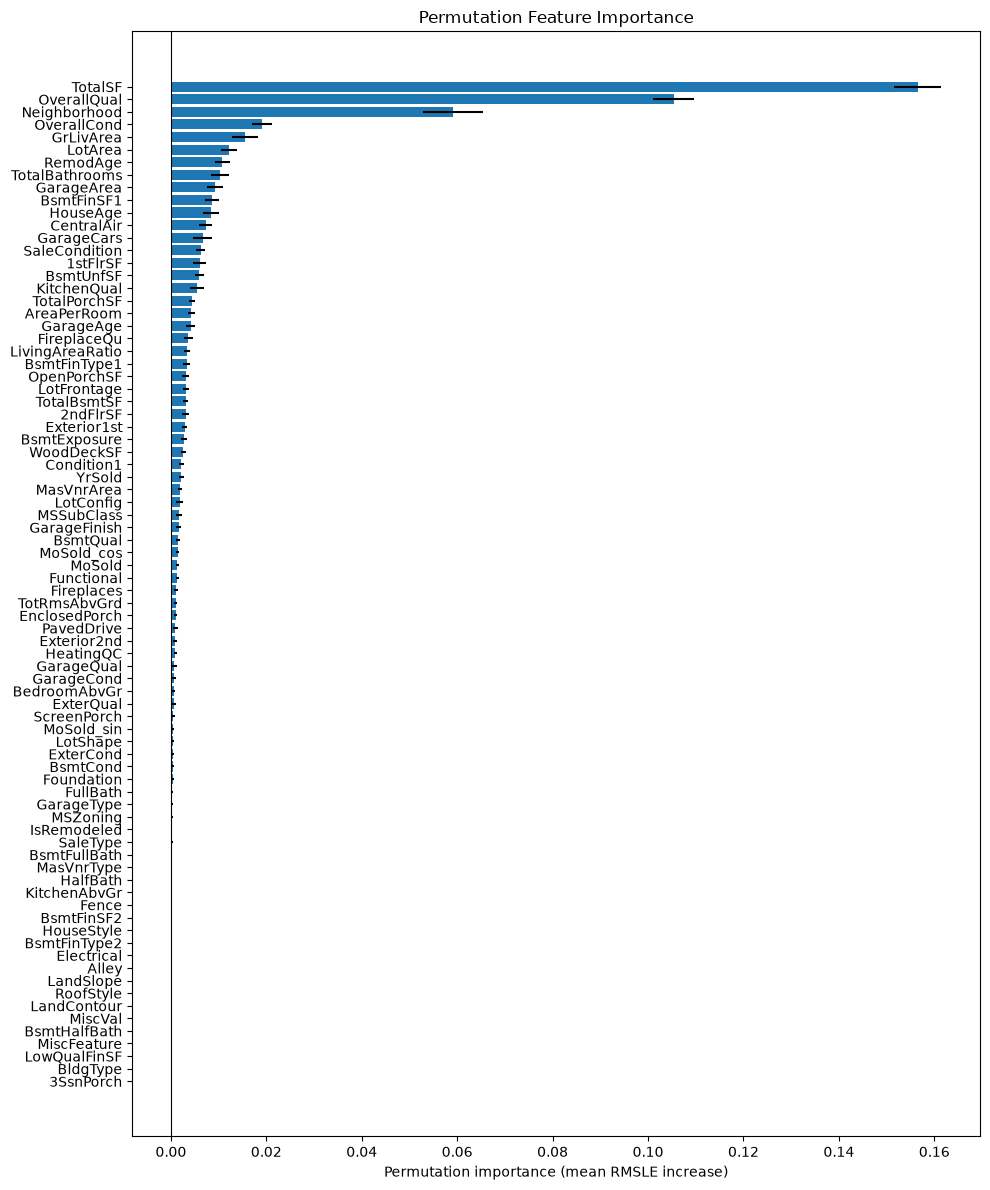

In [51]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, max(6, len(perm_result) * 0.15)))

ax.barh(
    perm_result.index[::-1],
    perm_result["mean_importance"][::-1],
    xerr=perm_result["std_importance"][::-1],
    color=[
        "tab:red" if v <= 0 else "tab:blue"
        for v in perm_result["mean_importance"][::-1]
    ],
)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Permutation importance (mean RMSLE increase)")
ax.set_title("Permutation Feature Importance")
plt.tight_layout()
plt.show()

In [52]:
# useless
useless_mask = (perm_result["mean_importance"] - perm_result["std_importance"]) <= 0
useless_features = perm_result[useless_mask].index.tolist()

print(f"Кандидатов на удаление: {len(useless_features)} из {len(perm_result)}")
print(useless_features)

Кандидатов на удаление: 15 из 80
['ExterQual', 'MSZoning', 'SaleType', 'MasVnrType', 'HouseStyle', 'Electrical', 'LandSlope', 'RoofStyle', 'LandContour', 'MiscVal', 'BsmtHalfBath', 'MiscFeature', 'LowQualFinSF', 'BldgType', '3SsnPorch']


["MiscVal", "BsmtHalfBath", "LowQualFinSF", "3SsnPorch"] - под удаление, остальные пусть будут

In [ ]:
num_columns = [
    "LotFrontage",
    "LotArea",
    "OverallQual",
    "OverallCond",
    # "YearBuilt",        # удалено -> заменено на HouseAge
    # "YearRemodAdd",     # удалено -> заменено на RemodAge
    "MasVnrArea",
    "BsmtFinSF1",
    "BsmtFinSF2",
    "BsmtUnfSF",
    "TotalBsmtSF",
    "1stFlrSF",
    "2ndFlrSF",
    # "LowQualFinSF",   # исключено - useless_features (permutation importance)
    "GrLivArea",
    "BsmtFullBath",
    # "BsmtHalfBath",   # исключено - useless_features (permutation importance)
    "FullBath",
    "HalfBath",
    "BedroomAbvGr",
    "KitchenAbvGr",
    "TotRmsAbvGrd",
    "Fireplaces",
    # "GarageYrBlt",      # удалено -> заменено на GarageAge
    "GarageCars",
    "GarageArea",
    "WoodDeckSF",
    "OpenPorchSF",
    "EnclosedPorch",
    # "3SsnPorch",      # исключено - useless_features (permutation importance)
    "ScreenPorch",
    "PoolArea",  # лучше пусть останется упоминание о бассейне
    # "MiscVal",        # исключено - useless_features (permutation importance)
    "MoSold",
    "YrSold",
    # --- новые непрерывные/счётные признаки ---
    "HouseAge",
    "RemodAge",
    "GarageAge",
    "TotalSF",
    "TotalBathrooms",
    "TotalPorchSF",
    "AreaPerRoom",
    "LivingAreaRatio",
    "MoSold_sin",
    "MoSold_cos",
    # --- бинарные флаги (0/1) ---
    "IsRemodeled",
    # "IsNewHouse",   # исключено - useless_features
    # "HasPool",      # исключено - useless_features
    # "HasGarage",    # исключено - useless_features
    # "HasBsmt",      # исключено - useless_features
    # "HasFireplace", # исключено - useless_features
    # "Has2ndFloor",  # исключено - useless_features
]

ordinal_columns = [
    "LotShape",
    "LandSlope",
    "ExterQual",
    "ExterCond",
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2",
    "HeatingQC",
    "KitchenQual",
    "Functional",
    "FireplaceQu",
    "GarageFinish",
    "GarageQual",
    "GarageCond",
    "PavedDrive",
    # "PoolQC",   # исключено - useless_features
    "CentralAir",
]

ordinal_categories = [
    # порядок соответствует ordinal_columns выше (PoolQC и его категория удалены)
    ["IR3", "IR2", "IR1", "Reg"],
    ["Sev", "Mod", "Gtl"],
    ["Po", "Fa", "TA", "Gd", "Ex"],
    ["Po", "Fa", "TA", "Gd", "Ex"],
    ["None", "Po", "Fa", "TA", "Gd", "Ex"],
    ["None", "Po", "Fa", "TA", "Gd", "Ex"],
    ["None", "No", "Mn", "Av", "Gd"],
    ["None", "Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],
    ["None", "Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],
    ["Po", "Fa", "TA", "Gd", "Ex"],
    ["Po", "Fa", "TA", "Gd", "Ex"],
    ["Sal", "Sev", "Maj2", "Maj1", "Mod", "Min2", "Min1", "Typ"],
    ["None", "Po", "Fa", "TA", "Gd", "Ex"],
    ["None", "Unf", "RFn", "Fin"],
    ["None", "Po", "Fa", "TA", "Gd", "Ex"],
    ["None", "Po", "Fa", "TA", "Gd", "Ex"],
    ["N", "P", "Y"],
    # ["None", "Fa", "TA", "Gd", "Ex"],  # было для PoolQC - удалено
    ["N", "Y"],
]

ohe_columns = [
    "Fence",
    "Electrical",
    "MSSubClass",
    "MSZoning",
    # "Street",        # исключено - useless_features
    "Alley",
    "LandContour",
    "LotConfig",
    "Neighborhood",
    "Condition1",
    # "Condition2",    # исключено - useless_features
    "BldgType",
    "HouseStyle",
    "RoofStyle",
    # "RoofMatl",      # исключено - useless_features
    "Exterior1st",
    "Exterior2nd",
    "MasVnrType",
    "Foundation",
    # "Heating",       # исключено - useless_features
    "GarageType",
    "MiscFeature",
    "SaleType",
    "SaleCondition",
]
pipe = Pipeline(
    [
        ("memory_optimizer", MemoryOptimizer()),
        (
            "column_transformer",
            ColumnTransformer(
                transformers=[
                    ("num_features", "passthrough", num_columns),
                    (
                        "cat_features_oe",
                        OrdinalEncoder(
                            categories=ordinal_categories,
                            handle_unknown="use_encoded_value",
                            unknown_value=-1,
                        ),
                        ordinal_columns,
                    ),
                    (
                        "cat_features_ohe",
                        "passthrough",
                        ohe_columns,
                    ),
                ],
                verbose_feature_names_out=False,
            ).set_output(transform="pandas"),
        ),
        ("to_category", ToCategory(ohe_columns)),
    ]
)

assert len(ordinal_columns) == len(ordinal_categories), (
    "Рассинхрон между колонками и категориями!"
)

In [ ]:
X_train = X_train.drop(columns=["MiscVal", "BsmtHalfBath", "LowQualFinSF", "3SsnPorch"])


KeyError: "['MiscVal', 'BsmtHalfBath', 'LowQualFinSF', '3SsnPorch'] not found in axis"

In [65]:
X_train.shape

(1460, 76)

In [66]:
print(len(num_columns) + len(ordinal_columns) + len(ohe_columns))

77


In [59]:
fitted_models, oof_preds, metrics, val_scores = cv_result(
    baseline_model, X_train, y_train, y_binned, rskf, pipe, "baseline_model"
)
metrics

,model,TRAIN_rmsle_MEAN,TRAIN_rmsle_STD,VAL_rmsle_MEAN,VAL_rmsle_STD,OOF_rmsle
0,baseline_model,0.038584,0.000701,0.12805,0.014555,0.125416


### Итог
Как минимум новые фичи не сделали хуже

In [ ]:
print("num_columns =", num_columns)

num_columns = ['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'GrLivArea', 'BsmtFullBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', 'ScreenPorch', 'PoolArea', 'MoSold', 'YrSold', 'HouseAge', 'RemodAge', 'GarageAge', 'TotalSF', 'TotalBathrooms', 'TotalPorchSF', 'AreaPerRoom', 'LivingAreaRatio', 'MoSold_sin', 'MoSold_cos', 'IsRemodeled']


In [ ]:
print("ordinal_columns =", ordinal_columns)

ordinal_columns = ['LotShape', 'LandSlope', 'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'HeatingQC', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'CentralAir']


In [ ]:
print("ohe_columns =", ohe_columns)

ohe_columns = ['Fence', 'Electrical', 'MSSubClass', 'MSZoning', 'Alley', 'LandContour', 'LotConfig', 'Neighborhood', 'Condition1', 'BldgType', 'HouseStyle', 'RoofStyle', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation', 'GarageType', 'MiscFeature', 'SaleType', 'SaleCondition']
